In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('CFD_ML_Baffle_Dataset.csv')
df.head()

,Re,Phi,Theta,Nu,PressureDrop,PEC
0,1000,0.0,0,12.560905,4.583571,1.0000
1,1000,0.0,30,13.502973,4.583571,1.0750
2,1000,0.0,45,13.974007,4.583571,1.1125
3,1000,0.0,60,14.445041,4.583571,1.1500
4,1000,0.0,90,15.387109,4.583571,1.2250


In [3]:
df.shape

(330, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Re            330 non-null    int64  
 1   Phi           330 non-null    float64
 2   Theta         330 non-null    int64  
 3   Nu            330 non-null    float64
 4   PressureDrop  330 non-null    float64
 5   PEC           330 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 15.6 KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,Re,Phi,Theta,Nu,PressureDrop,PEC
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,3500.000000,0.025000,45.000000,36.380257,44.456483,1.135319
std,1583.539953,0.017104,30.045558,13.922987,31.021992,0.077614
min,1000.000000,0.000000,0.000000,11.956496,4.237217,1.000000
25%,2000.000000,0.010000,30.000000,24.833666,15.016479,1.089029
50%,3500.000000,0.025000,45.000000,36.784624,38.883224,1.140356
75%,5000.000000,0.040000,60.000000,48.068371,71.285257,1.184143
max,6000.000000,0.050000,90.000000,64.517575,105.431084,1.262059


In [7]:
df.columns

Index(['Re', 'Phi', 'Theta', 'Nu', 'PressureDrop', 'PEC'], dtype='object')

In [8]:
df.corr()['Nu']

Re              0.979920
Phi            -0.043949
Theta           0.176422
Nu              1.000000
PressureDrop    0.962846
PEC             0.167533
Name: Nu, dtype: float64

In [9]:
df.corr(method='kendall')['Nu']

Re              0.905024
Phi            -0.036248
Theta           0.130995
Nu              1.000000
PressureDrop    0.888071
PEC             0.105329
Name: Nu, dtype: float64

In [10]:
df.corr(method='spearman')['Nu']

Re              0.981087
Phi            -0.046798
Theta           0.172005
Nu              1.000000
PressureDrop    0.981332
PEC             0.159194
Name: Nu, dtype: float64

<Axes: >

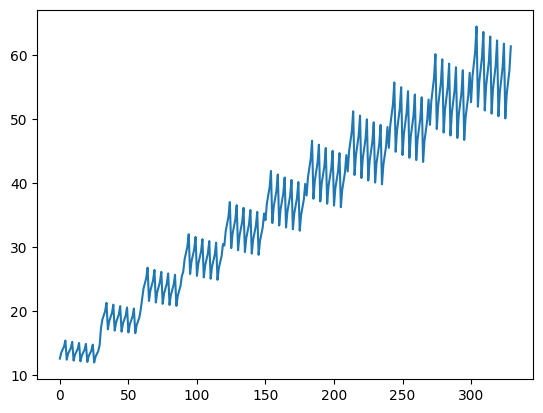

In [11]:
df['Nu'].plot(kind='line')

<Axes: xlabel='Nu', ylabel='Re'>

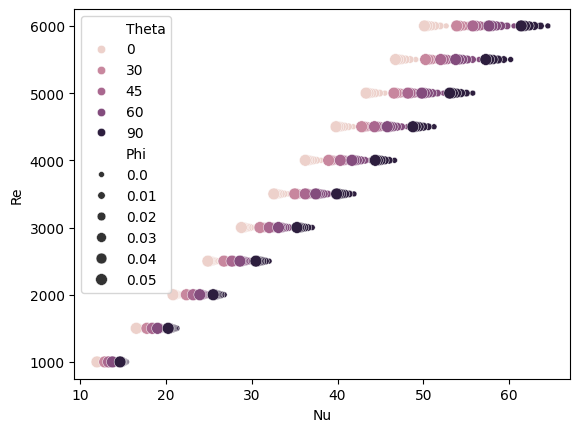

In [12]:
sns.scatterplot(x=df['Nu'],y=df['Re'],hue=df['Theta'],size=df['Phi'])

<Axes: >

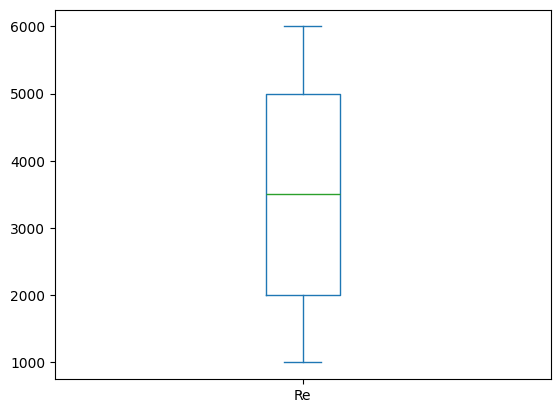

In [13]:
df['Re'].plot(kind='box')

<Axes: ylabel='Density'>

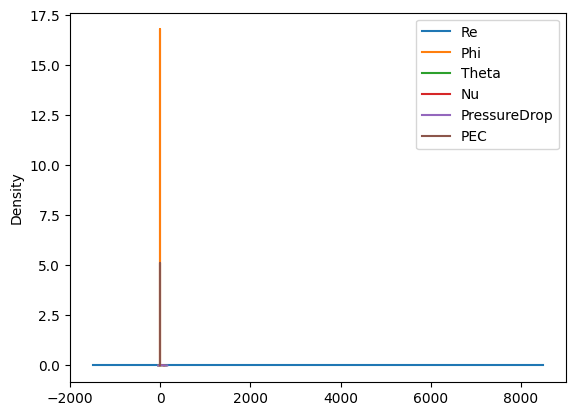

In [14]:
df.plot(kind='kde')

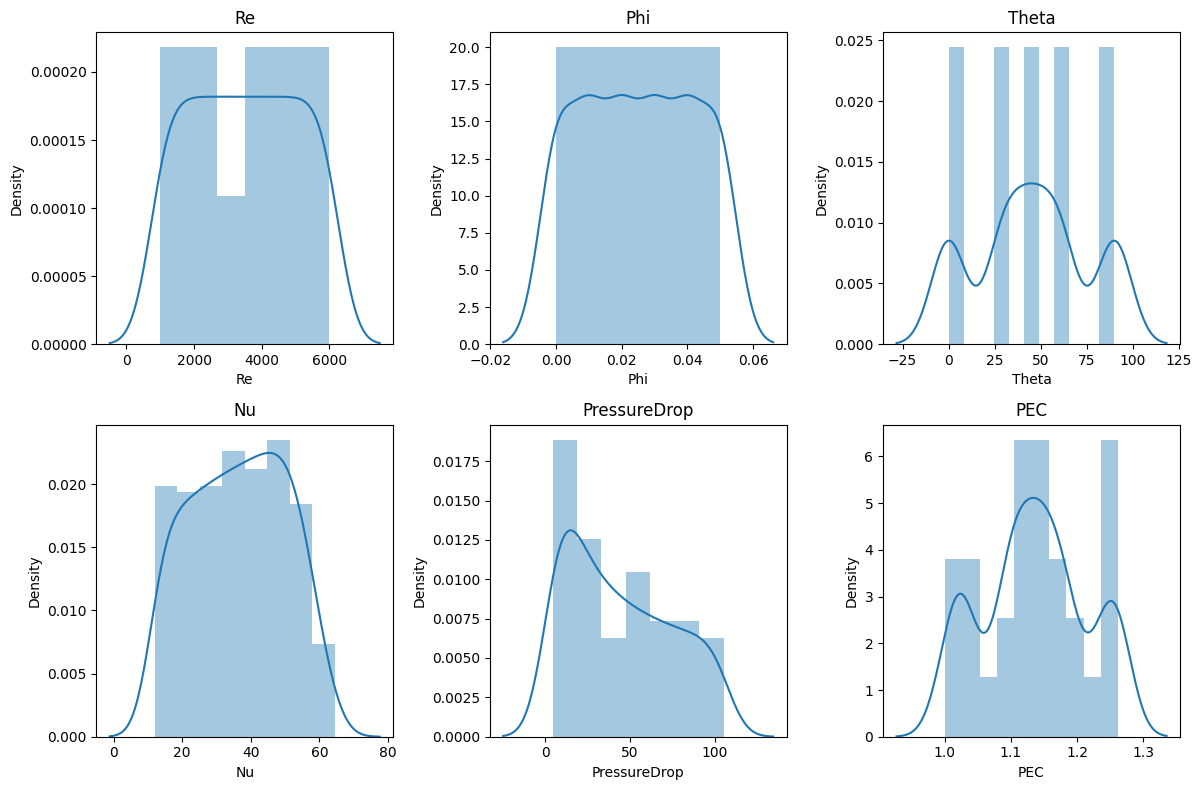

In [15]:
import math
cols = df.columns
fig, axes = plt.subplots(math.ceil(len(cols)/3), 3, figsize=(12, 4*math.ceil(len(cols)/3)))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.distplot(df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

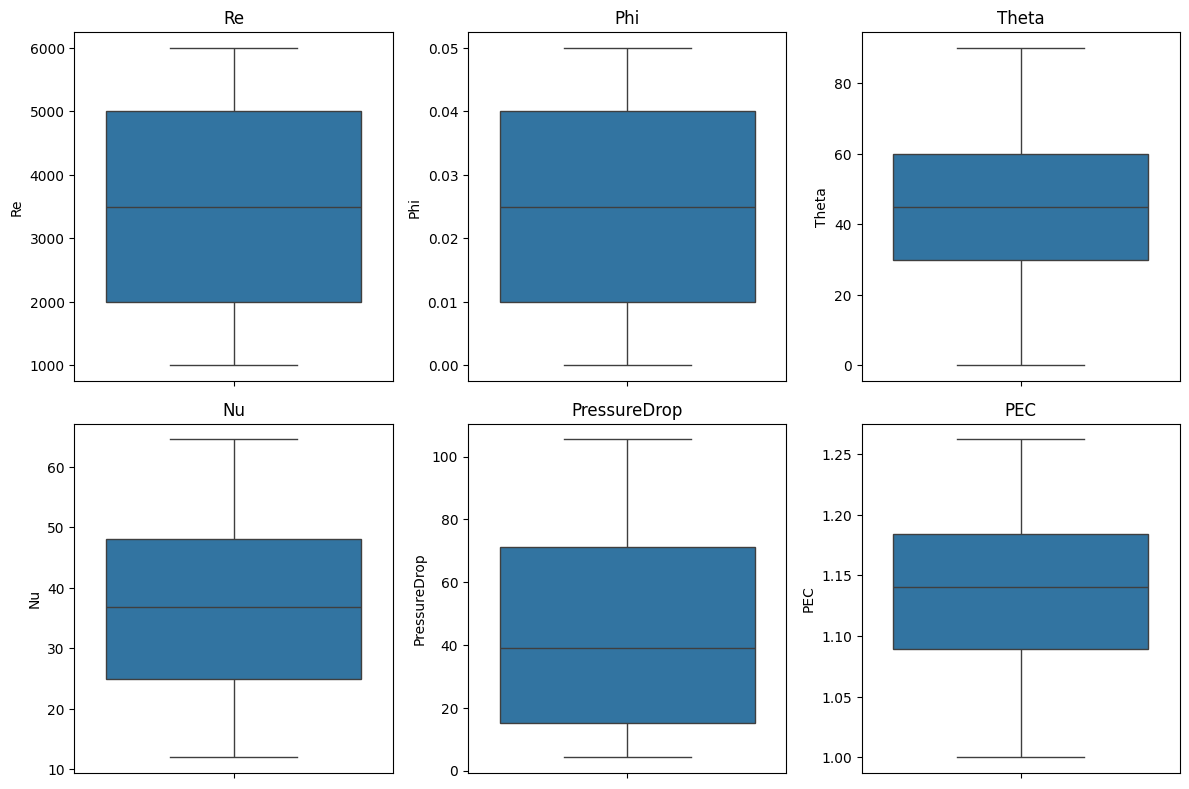

In [16]:
import math
cols = df.columns
fig, axes = plt.subplots(math.ceil(len(cols)/3), 3, figsize=(12, 4*math.ceil(len(cols)/3)))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

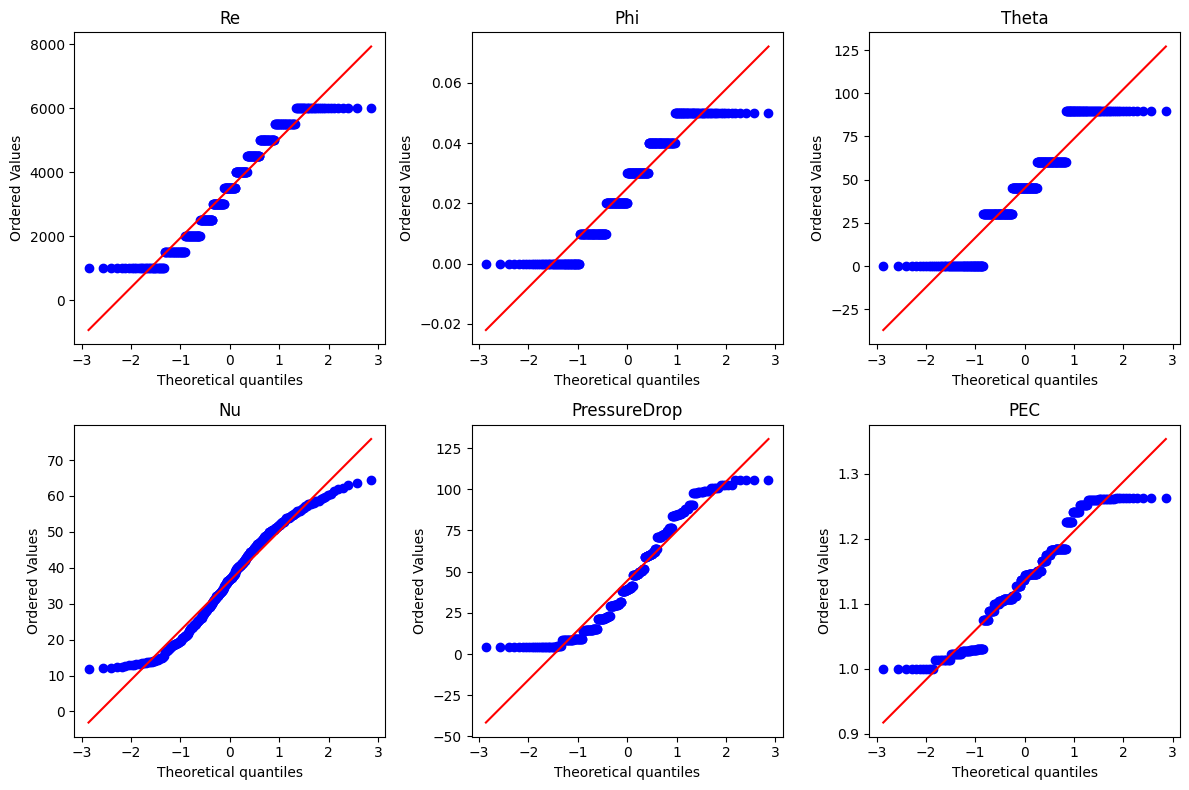

In [17]:
import math
import scipy.stats as stats
cols = df.columns
fig, axes = plt.subplots(math.ceil(len(cols)/3), 3, figsize=(12, 4*math.ceil(len(cols)/3)))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(df[col],dist='norm',plot=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

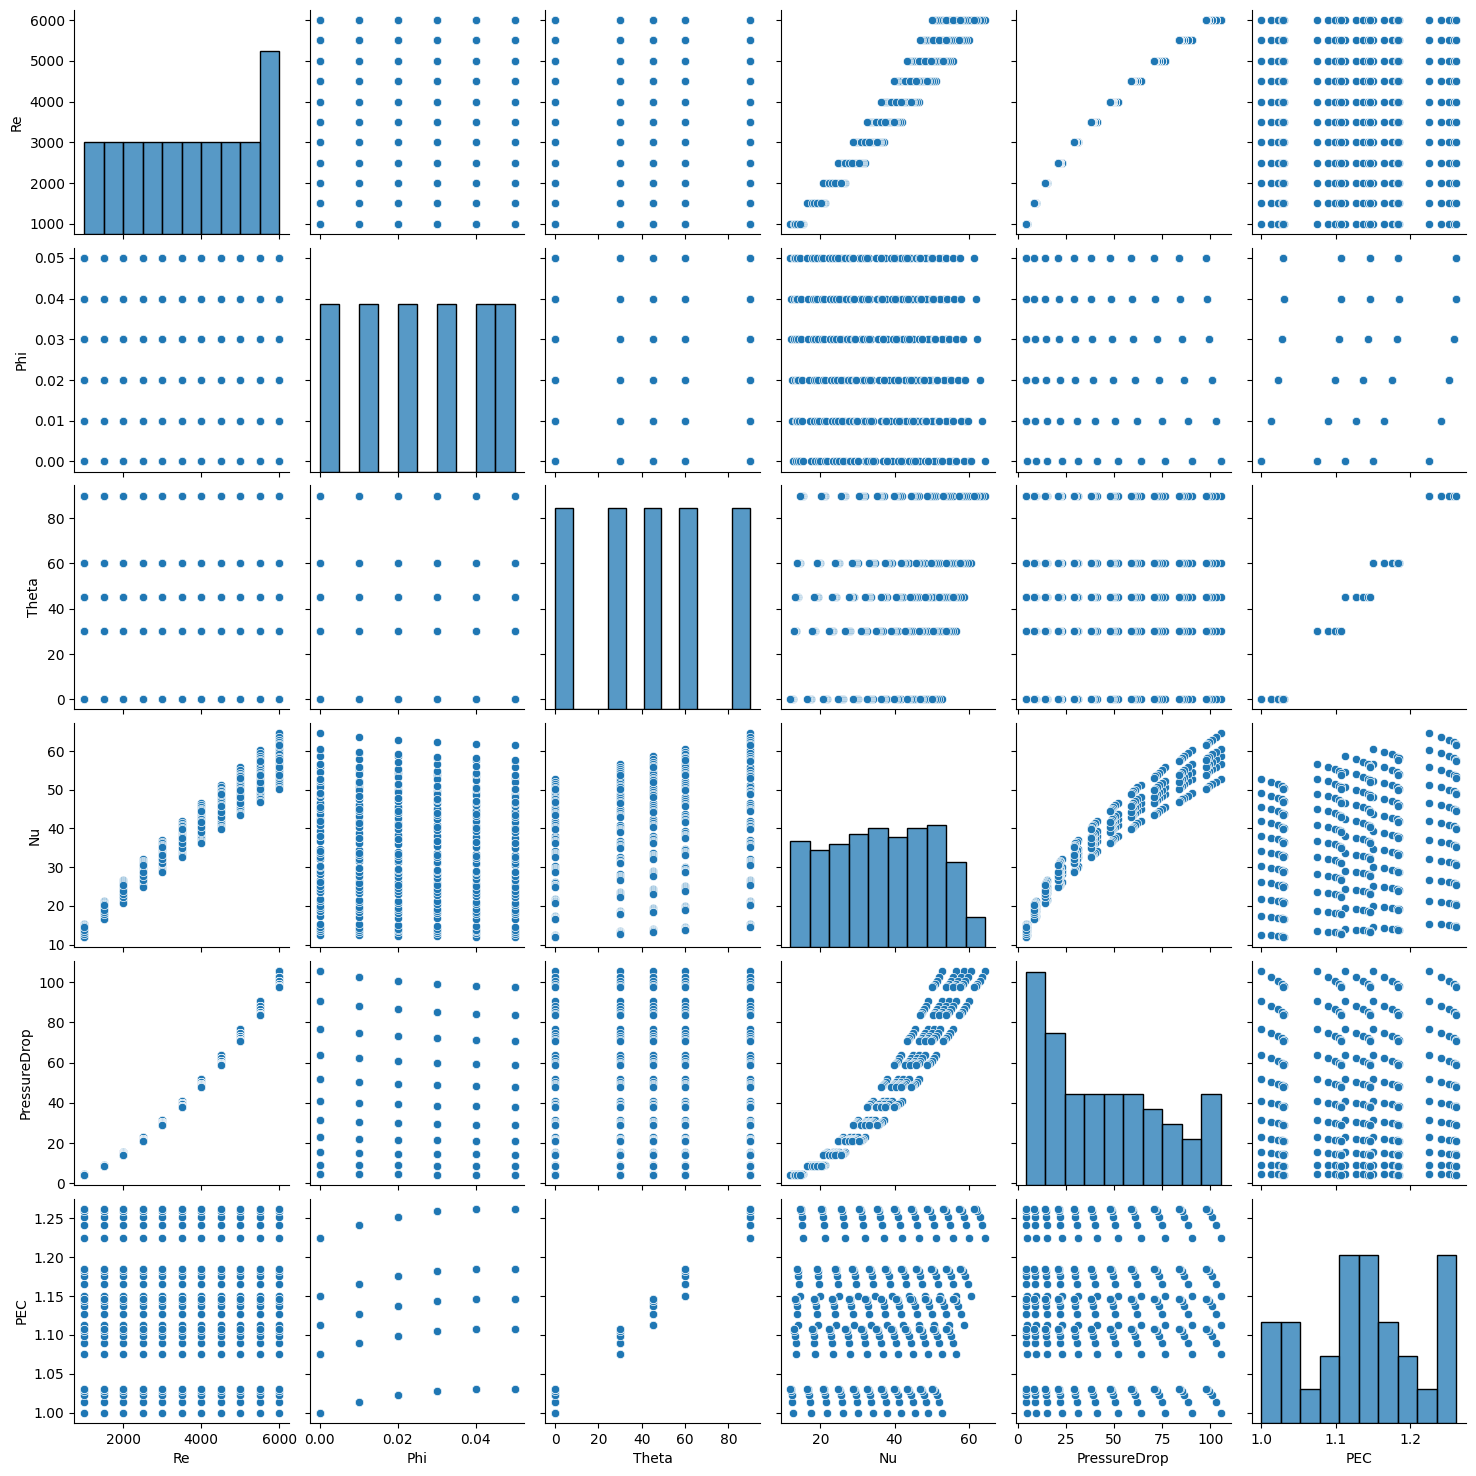

In [18]:
sns.pairplot(df)


In [19]:
from scipy.stats import shapiro

for col in df.columns:
    stat, p = shapiro(df[col])
    print(f'{col}: Statistics={stat:.3f}, p={p:.3f}', end=' → ')
    if p > 0.05:
        print("Normal")
    else:
        print("Not Normal")


Re: Statistics=0.938, p=0.000 → Not Normal
Phi: Statistics=0.906, p=0.000 → Not Normal
Theta: Statistics=0.895, p=0.000 → Not Normal
Nu: Statistics=0.965, p=0.000 → Not Normal
PressureDrop: Statistics=0.924, p=0.000 → Not Normal
PEC: Statistics=0.946, p=0.000 → Not Normal


In [20]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [80]:
y = df.iloc[:,3]
X = df.drop(df.columns[3], axis=1)

In [81]:
X.columns

Index(['Re', 'Phi', 'Theta', 'PressureDrop', 'PEC'], dtype='object')

In [82]:
X.shape,y.shape

((330, 5), (330,))

In [201]:
X_train,X_test,y_trains,y_test=train_test_split(X,y, test_size=0.25,random_state=42)

In [202]:
y_trains

31     18.676798
223    46.940354
196    39.550393
152    38.069345
227    44.974296
         ...    
188    43.207525
71     22.935646
106    27.155313
270    49.125965
102    28.374652
Name: Nu, Length: 247, dtype: float64

<Axes: ylabel='Density'>

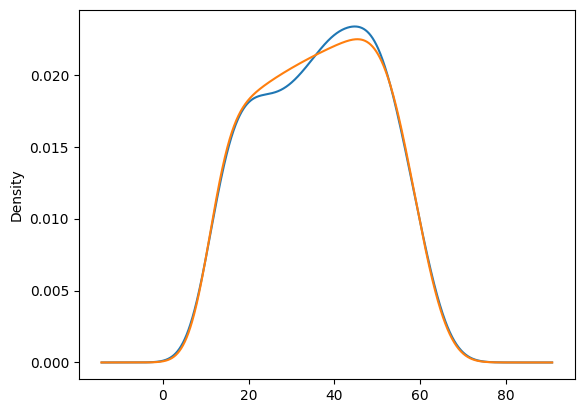

In [203]:
y_trains.plot(kind='kde')
y.plot(kind='kde')

In [204]:
y_train = np.log1p(y_trains) 


<Axes: ylabel='Density'>

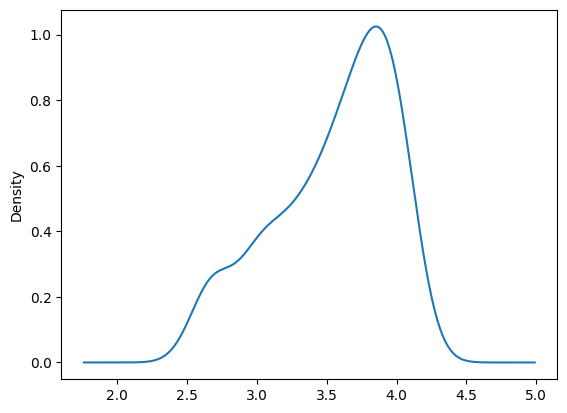

In [205]:
y_train.plot(kind='kde')


<Axes: ylabel='Density'>

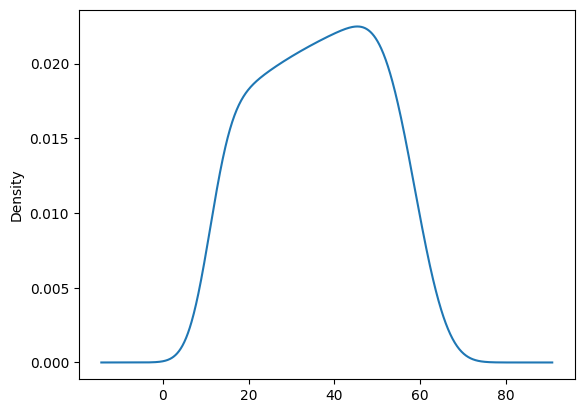

In [206]:
y.plot(kind='kde')

In [207]:
rf = RandomForestRegressor(random_state=42)

In [208]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [209]:

y_pred_log_rf = rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_log_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)
mae_rf,mse_rf**0.5,r2_rf

(0.4039333072195202, 0.5723329114091966, 0.998322674767392)

In [210]:

y_true_rf = y_test.values.flatten()
y_pred_flat_rf = y_pred_rf.flatten()    

comparison = pd.DataFrame({
    'Actual': y_true_rf,
    'Predicted': y_pred_flat_rf,
    'Error': y_true_rf - y_pred_flat_rf,
    'Absolute_Error': np.abs(y_true_rf - y_pred_flat_rf)
})

comparison.iloc[:10]


,Actual,Predicted,Error,Absolute_Error
0,15.182722,15.112767,0.069955,0.069955
1,40.894889,40.414648,0.480242,0.480242
2,35.803661,35.767093,0.036568,0.036568
3,18.045786,18.092102,-0.046315,0.046315
4,32.026468,31.342884,0.683584,0.683584
5,27.418203,27.575487,-0.157285,0.157285
6,25.675741,25.441255,0.234487,0.234487
7,55.234188,54.358092,0.876096,0.876096
8,54.704595,54.053323,0.651271,0.651271
9,50.573109,50.097995,0.475114,0.475114


In [189]:
scores = cross_val_score(rf, X_test, y_test, cv=5, scoring='neg_mean_squared_error')
scores


array([-0.00250069, -0.00253149, -0.00236215, -0.00306193, -0.00161996])

In [190]:
comparison.shape,X_test.shape,X_test.columns

((83, 4),
 (83, 5),
 Index(['Re', 'Phi', 'Theta', 'PressureDrop', 'PEC'], dtype='object'))

In [191]:
X_test.columns

Index(['Re', 'Phi', 'Theta', 'PressureDrop', 'PEC'], dtype='object')

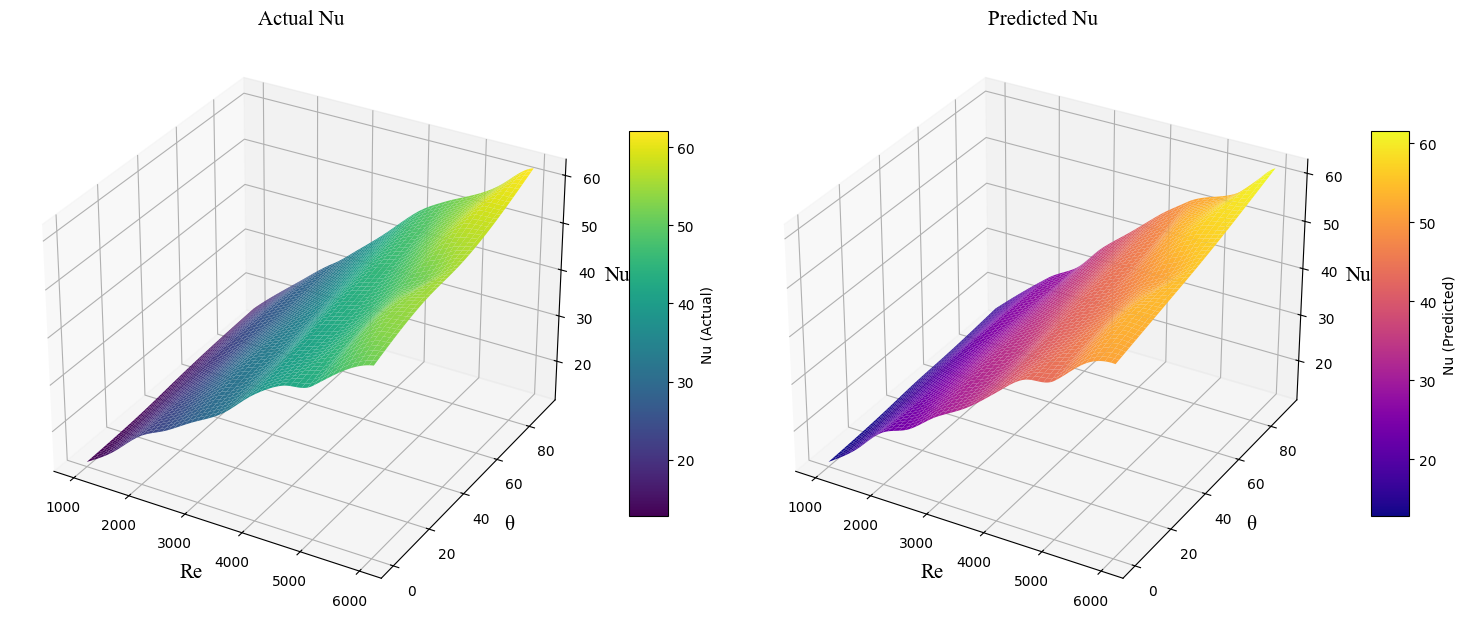

In [126]:

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D 

# Data
X_rf_Ha = X_test['Re']
Y_rf_Ha = X_test['Theta'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

# Grid
xi = np.linspace(X_rf_Ha.min(), X_rf_Ha.max(), 200)
yi = np.linspace(Y_rf_Ha.min(), Y_rf_Ha.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_rf_Ha, Y_rf_Ha), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_rf_Ha, Y_rf_Ha), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu",fontsize=15, fontname="Times New Roman")
ax1.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu",fontsize=15, fontname="Times New Roman")
ax2.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(Re,θ).png",dpi=600)
plt.show()

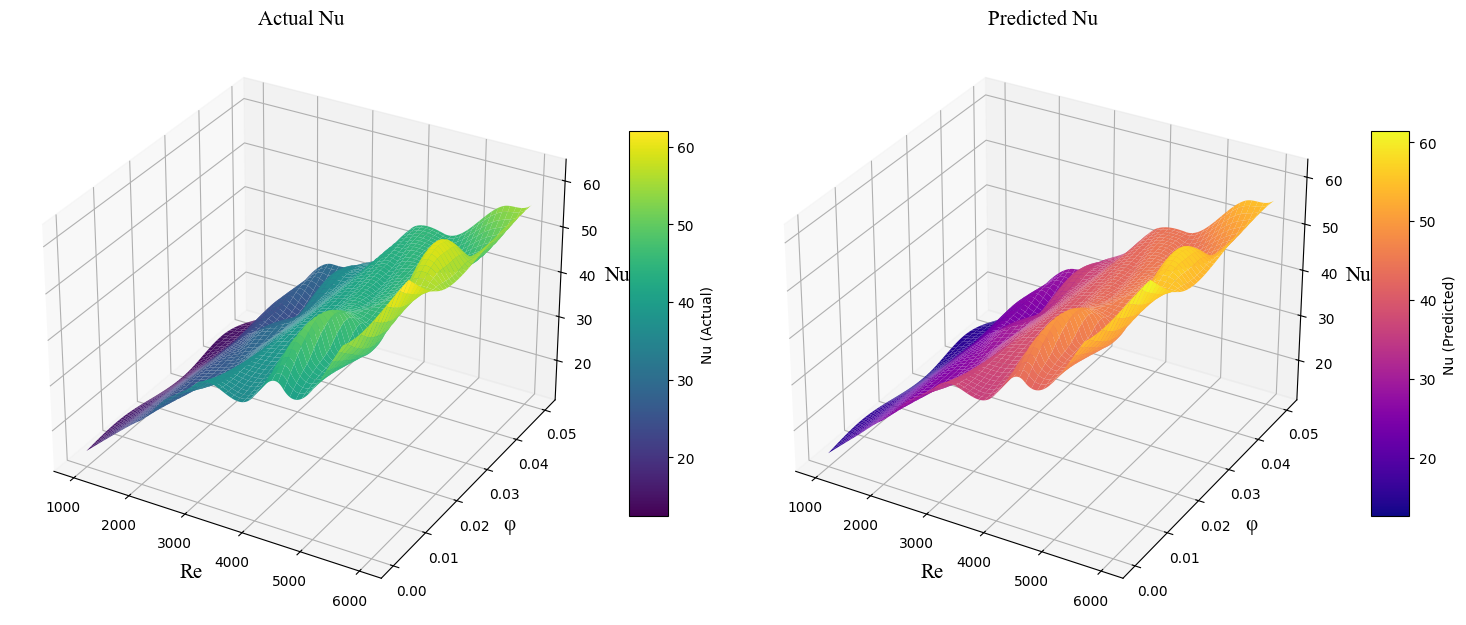

In [127]:

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D 

# Data
X_rf_θ = X_test['Re']
Y_rf_θ = X_test['Phi'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

# Grid
xi = np.linspace(X_rf_θ.min(), X_rf_θ.max(), 200)
yi = np.linspace(Y_rf_θ.min(), Y_rf_θ.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_rf_θ, Y_rf_θ), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_rf_θ, Y_rf_θ), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu",fontsize=15, fontname="Times New Roman")
ax1.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("φ",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu",fontsize=15, fontname="Times New Roman")
ax2.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("φ",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(Re,φ).png",dpi=600)
plt.show()

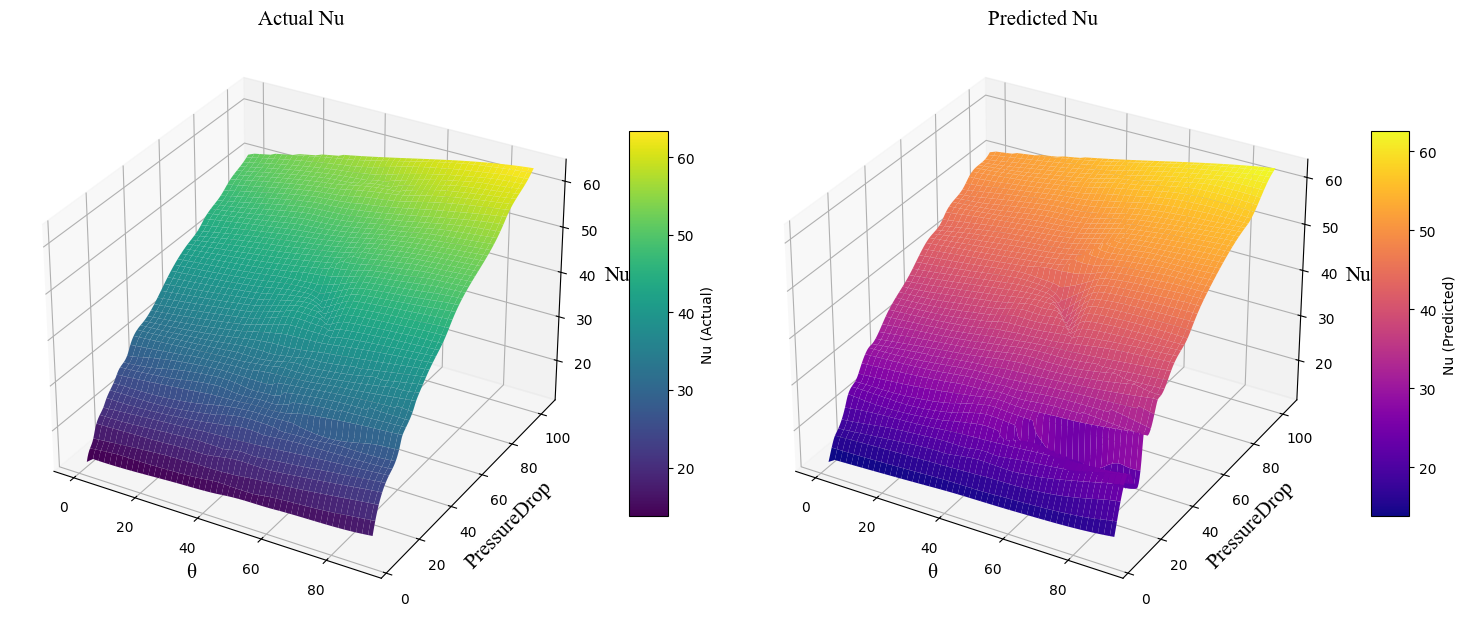

In [128]:

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D 

# Data
X_rf = X_test['Theta']
Y_rf = X_test['PressureDrop'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

# Grid
xi = np.linspace(X_rf.min(), X_rf.max(), 200)
yi = np.linspace(Y_rf.min(), Y_rf.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_rf, Y_rf), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_rf, Y_rf), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu",fontsize=15, fontname="Times New Roman")
ax1.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("PressureDrop",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu",fontsize=15, fontname="Times New Roman")
ax2.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("PressureDrop",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(θ,pd).png",dpi=600)
plt.show()

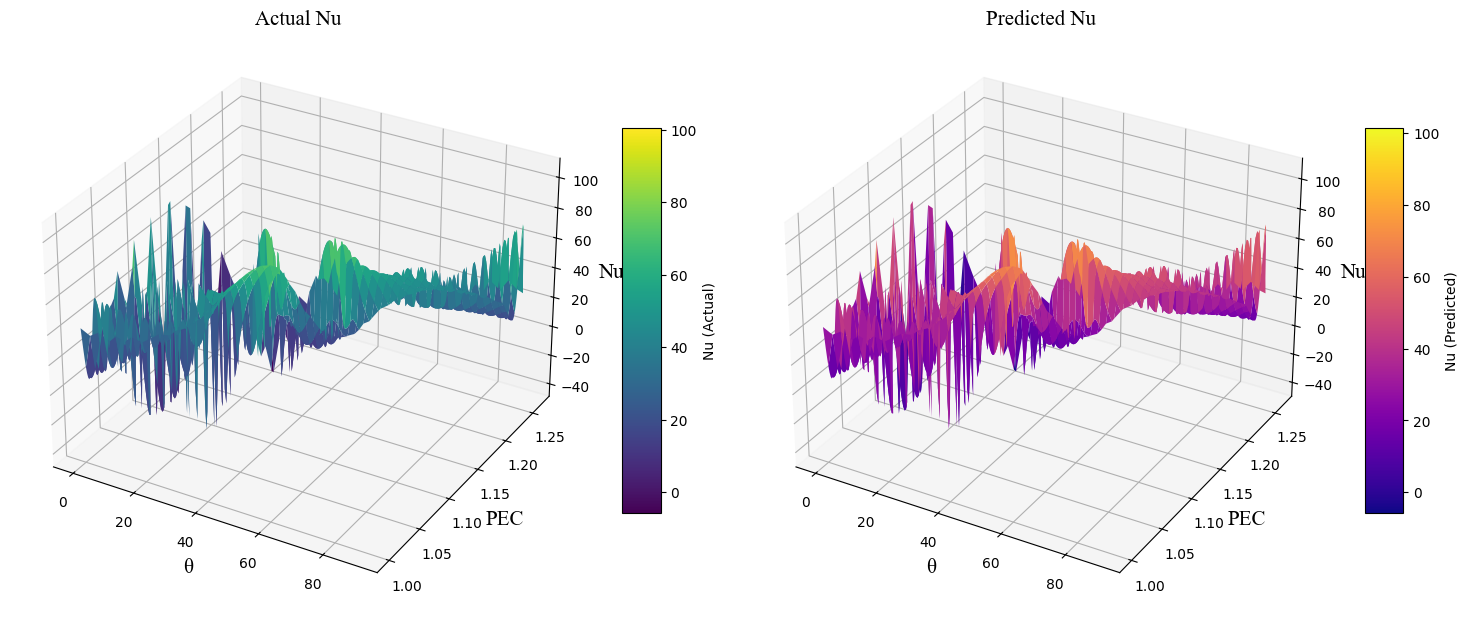

In [129]:

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D 

# Data
X_rf = X_test['Theta']
Y_rf = X_test['PEC'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

# Grid
xi = np.linspace(X_rf.min(), X_rf.max(), 200)
yi = np.linspace(Y_rf.min(), Y_rf.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_rf, Y_rf), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_rf, Y_rf), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu",fontsize=15, fontname="Times New Roman")
ax1.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("PEC",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu",fontsize=15, fontname="Times New Roman")
ax2.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("PEC",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(θ,pec).png",dpi=600)
plt.show()

In [130]:
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred_rf).reshape(-1, 1)

lin = LinearRegression()
lin.fit(y_test_reshaped, y_pred_reshaped)

m = lin.coef_[0][0]    
c = lin.intercept_[0]    
m,c

(0.9905369053687162, 0.29773990390118144)

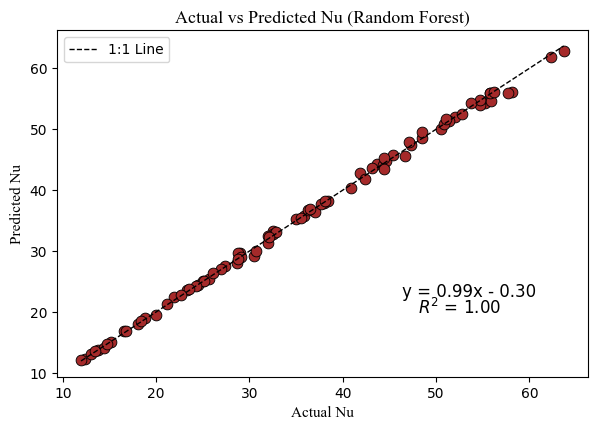

In [131]:

plt.figure(figsize=(6.85,4.5))
sns.scatterplot(x=comparison['Actual'], 
                y=comparison['Predicted'], 
                color='brown', edgecolor='black', s=60)

min_val = min(comparison['Actual'].min(), comparison['Predicted'].min())
max_val = max(comparison['Actual'].max(), comparison['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1,color="black",label='1:1 Line')
plt.text(0.65, 0.23, f'y = {m:.2f}x - {abs(c):.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.68, 0.18, f'$R^2$ = {r2_rf:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.xlabel("Actual Nu",fontsize=11, fontname="Times New Roman")
plt.ylabel("Predicted Nu",fontsize=11, fontname="Times New Roman")
plt.title("Actual vs Predicted Nu (Random Forest)",fontsize=13, fontname="Times New Roman")
# plt.grid(True)
plt.legend()
plt.savefig("Actual vs Predicted Scatterplot(RF).png",dpi=600)
plt.show()


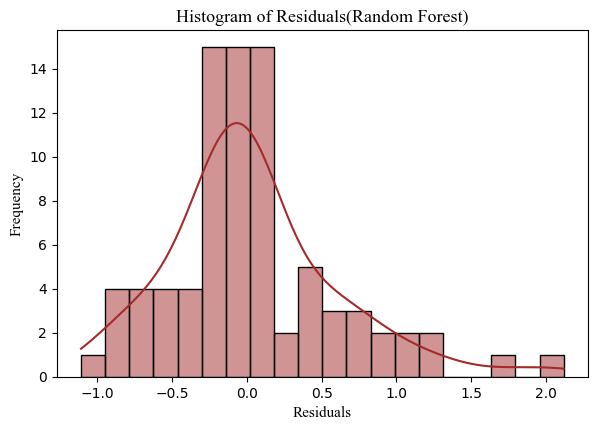

In [132]:
plt.figure(figsize=(6.85,4.5))
sns.histplot(comparison['Error'], bins=20,kde=True, color='brown')
plt.xlabel("Residuals",fontsize=11, fontname="Times New Roman")
plt.ylabel("Frequency",fontsize=11, fontname="Times New Roman")
plt.title("Histogram of Residuals(Random Forest)",fontsize=13, fontname="Times New Roman")
# plt.grid(True)
plt.savefig("Actual vs Predicted Scatterplot(RF).png",dpi=600)
plt.show()

<Axes: xlabel='Error', ylabel='Density'>

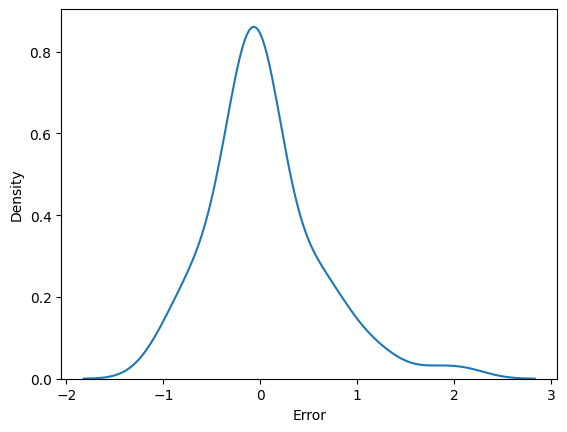

In [145]:
sns.kdeplot(comparison['Error'])

## XGBoost

In [133]:
from xgboost import XGBRegressor

xgb=XGBRegressor()
xgb.fit(X_train,y_train)



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [134]:
y_pred_log_xgb=xgb.predict(X_test)
y_pred_xgb=np.expm1(y_pred_log_xgb)

mse_xgb=mean_squared_error(y_test,y_pred_xgb)
mae_xgb=mean_absolute_error(y_test,y_pred_xgb)
r2_xgb=r2_score(y_test,y_pred_xgb)
mae_xgb,mse_xgb**0.5,r2_xgb

(0.30380954311754016, 0.4160813406972559, 0.9991135049396159)

In [135]:
y_true_xgb = y_test.values.flatten()
y_pred_flat_xgb = y_pred_xgb.flatten()    

comparison2 = pd.DataFrame({
    'Actual': y_true_xgb,
    'Predicted': y_pred_flat_xgb,
    'Error': y_true_xgb - y_pred_flat_xgb,
    'Absolute_Error': np.abs(y_true_xgb - y_pred_flat_xgb)
})

comparison2.iloc[:15]

,Actual,Predicted,Error,Absolute_Error
0,15.182722,15.024143,0.158579,0.158579
1,40.894889,40.247784,0.647106,0.647106
2,35.803661,35.796524,0.007137,0.007137
3,18.045786,18.434862,-0.389076,0.389076
4,32.026468,31.820995,0.205472,0.205472
5,27.418203,27.628386,-0.210183,0.210183
6,25.675741,25.457808,0.217934,0.217934
7,55.234188,54.714439,0.519749,0.519749
8,54.704595,54.391529,0.313066,0.313066
9,50.573109,50.695644,-0.122535,0.122535


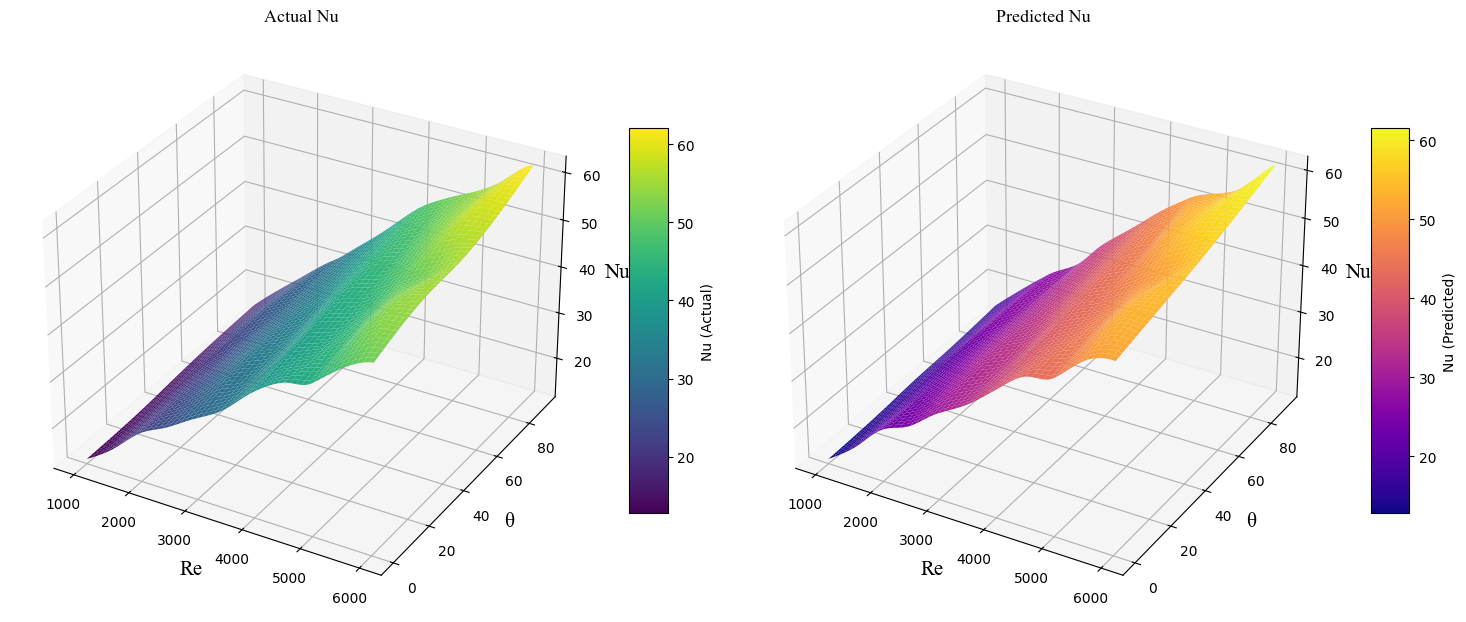

In [136]:

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D 

# Data
X_xgb_Ha = X_test['Re']
Y_xgb_Ha = X_test['Theta'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

# Grid
xi = np.linspace(X_xgb_Ha.min(), X_xgb_Ha.max(), 200)
yi = np.linspace(Y_xgb_Ha.min(), Y_xgb_Ha.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_xgb_Ha, Y_xgb_Ha), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_xgb_Ha, Y_xgb_Ha), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu",fontsize=13, fontname="Times New Roman")
ax1.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu",fontsize=13, fontname="Times New Roman")
ax2.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(Re,θ) XGBoost.png",dpi=600)
plt.show()


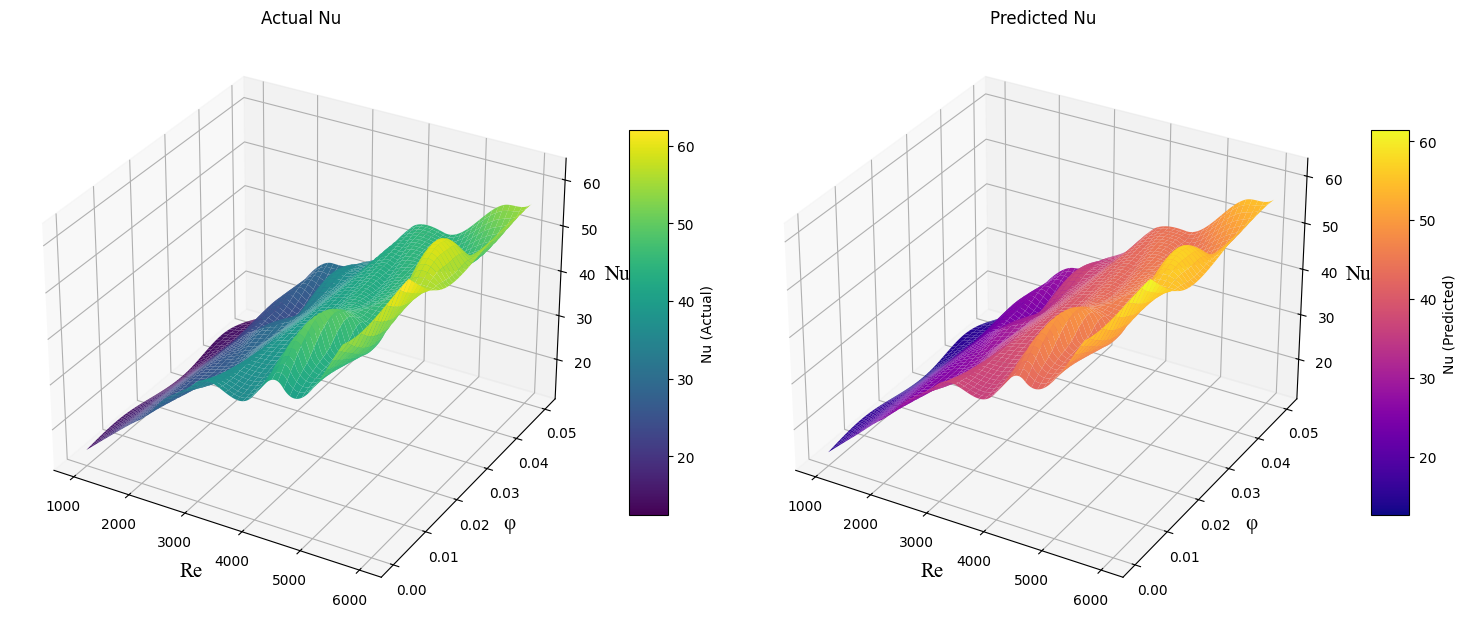

In [137]:

X_xgb = X_test['Re']
Y_xgb = X_test['Phi'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

xi = np.linspace(X_xgb.min(), X_xgb.max(), 200)
yi = np.linspace(Y_xgb.min(), Y_xgb.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_xgb, Y_xgb), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_xgb, Y_xgb), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu")
ax1.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("φ",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu")
ax2.set_xlabel("Re",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("φ",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(Re,φ) XGBoost.png",dpi=600)
plt.show()


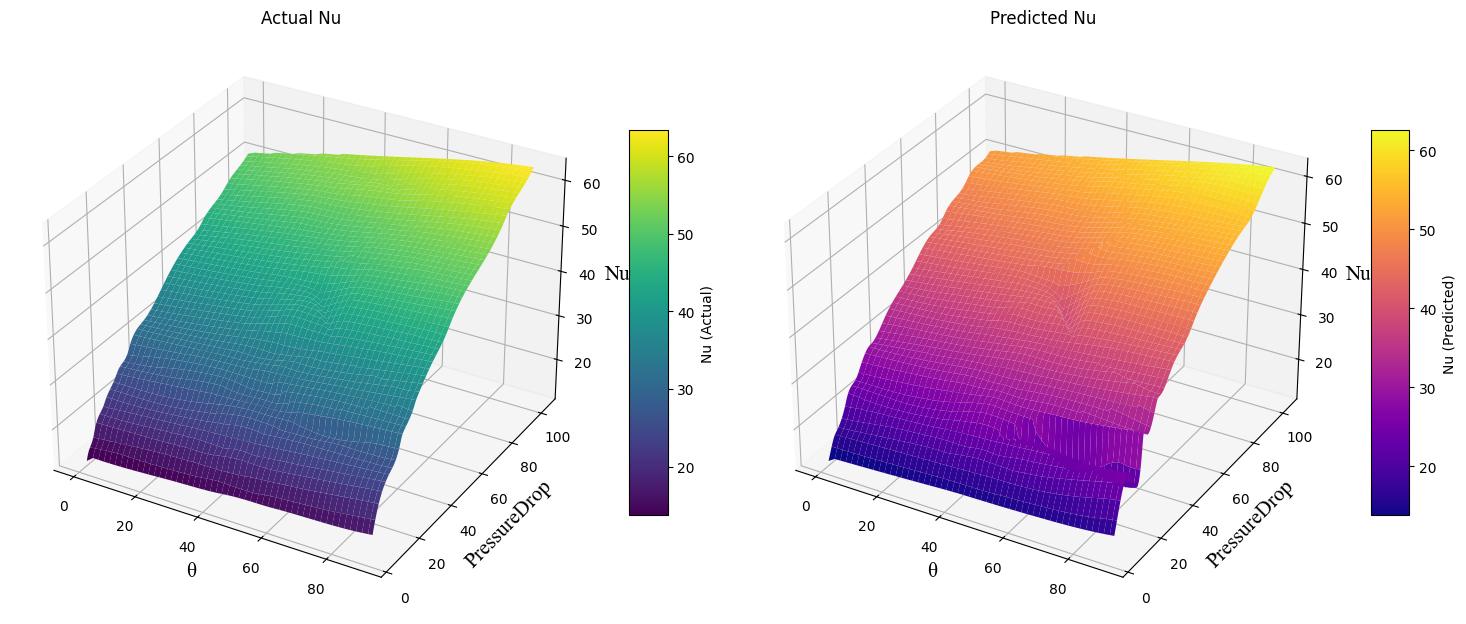

In [138]:

X_xgb = X_test['Theta']
Y_xgb = X_test['PressureDrop'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

xi = np.linspace(X_xgb.min(), X_xgb.max(), 200)
yi = np.linspace(Y_xgb.min(), Y_xgb.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_xgb, Y_xgb), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_xgb, Y_xgb), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu")
ax1.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("PressureDrop",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu")
ax2.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("PressureDrop",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(θ,pd) XGBoost.png",dpi=600)
plt.show()


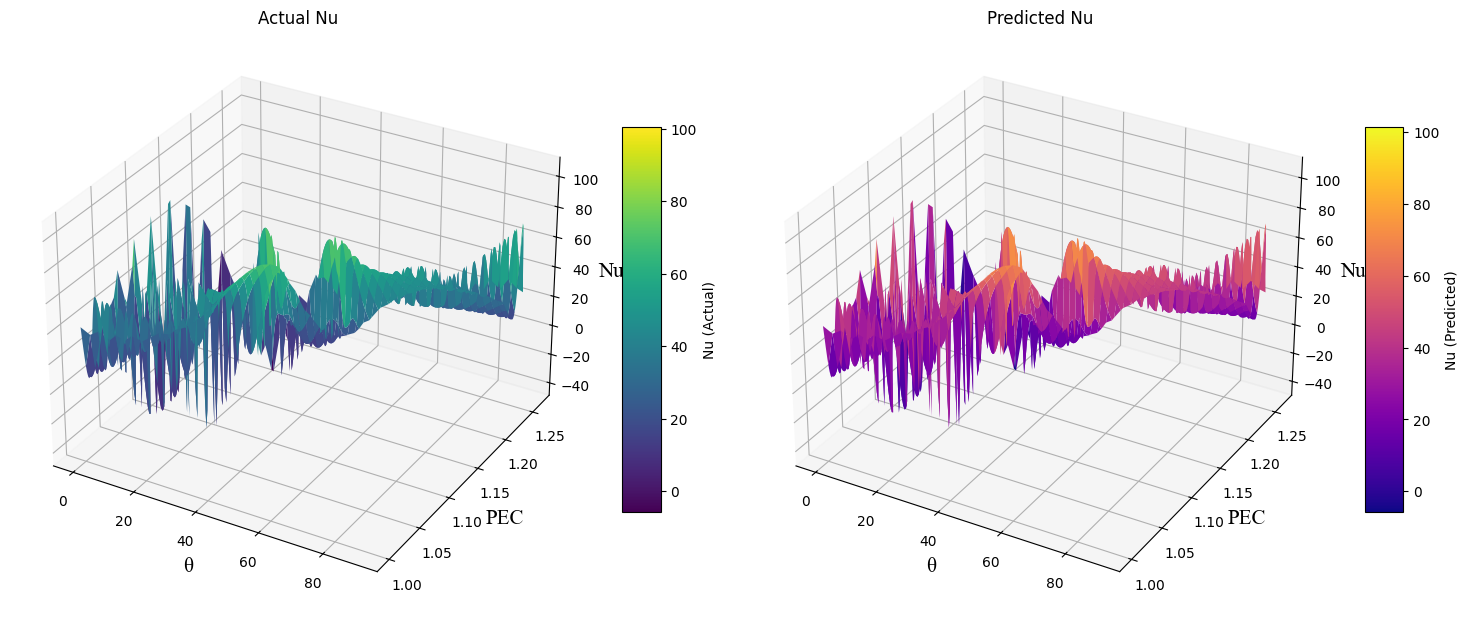

In [139]:

X_xgb = X_test['Theta']
Y_xgb = X_test['PEC'] 
Z_actual = comparison['Actual']
Z_pred = comparison['Predicted']

xi = np.linspace(X_xgb.min(), X_xgb.max(), 200)
yi = np.linspace(Y_xgb.min(), Y_xgb.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolation
Zi_actual = griddata((X_xgb, Y_xgb), Z_actual, (Xi, Yi), method='cubic')
Zi_pred   = griddata((X_xgb, Y_xgb), Z_pred,   (Xi, Yi), method='cubic')

# Figure and 3D Axes
fig = plt.figure(figsize=(15,8))

# Actual Surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(Xi, Yi, Zi_actual, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Nu (Actual)")
ax1.set_title("Actual Nu")
ax1.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax1.set_ylabel("PEC",fontsize=15, fontname="Times New Roman")
ax1.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

# Predicted Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xi, Yi, Zi_pred, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Nu (Predicted)")
ax2.set_title("Predicted Nu")
ax2.set_xlabel("θ",fontsize=15, fontname="Times New Roman")
ax2.set_ylabel("PEC",fontsize=15, fontname="Times New Roman")
ax2.set_zlabel("Nu",fontsize=15, fontname="Times New Roman")

plt.tight_layout()
plt.savefig("Actual vs Predicted 3D of Nu(θ,PEC) XGBoost.png",dpi=600)
plt.show()


In [142]:
y_test_reshaped_xgb = np.array(y_test).reshape(-1, 1)
y_pred_reshaped_xgb = np.array(y_pred_xgb).reshape(-1, 1)

li = LinearRegression()
li.fit(y_test_reshaped, y_pred_reshaped_xgb)

m_xgb = li.coef_[0][0]    
c_xgb = li.intercept_[0]    
m_xgb,c_xgb

(0.9964977341207538, 0.20652168034094132)

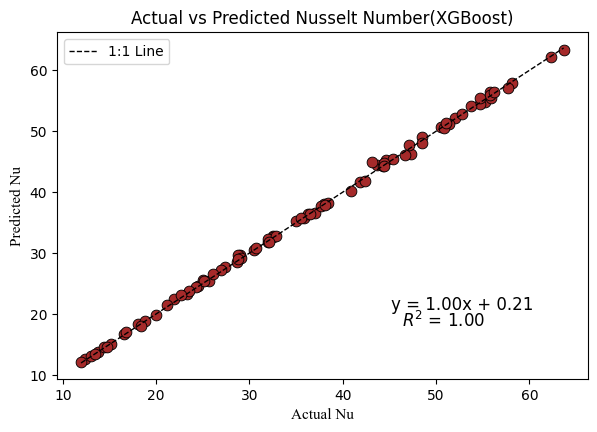

In [143]:

plt.figure(figsize=(6.85,4.5))
sns.scatterplot(x=comparison2['Actual'], 
                y=comparison2['Predicted'], 
                color='brown', edgecolor='black', s=60)

min_val_xgb = min(comparison2['Actual'].min(), comparison2['Predicted'].min())
max_val_xgb = max(comparison2['Actual'].max(), comparison2['Predicted'].max())
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], 'r--', linewidth=1,color="black",label='1:1 Line')
plt.text(0.63, 0.2, f'y = {m_xgb:.2f}x + {abs(c_xgb):.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_xgb:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.xlabel("Actual Nu",fontsize=11, fontname="Times New Roman")
plt.ylabel("Predicted Nu",fontsize=11, fontname="Times New Roman")
plt.title("Actual vs Predicted Nusselt Number(XGBoost)")
# plt.grid(True)
plt.legend()
plt.savefig('Actual vs Predicted Scatterplot(XGBoost).png',dpi=600)
plt.show()


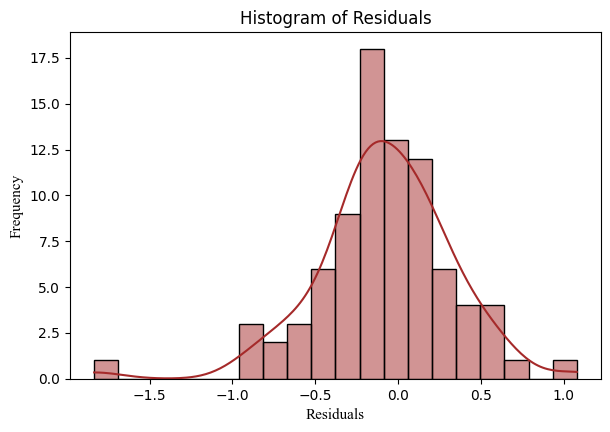

In [144]:
plt.figure(figsize=(6.85,4.5))
sns.histplot(comparison2['Error'], bins=20, kde=True, color='brown')
plt.xlabel("Residuals",fontsize=11, fontname="Times New Roman")
plt.ylabel("Frequency",fontsize=11, fontname="Times New Roman")
plt.title("Histogram of Residuals")
# plt.grid(True)
plt.savefig("Actual vs Predicted Residual plot(XGBoost).png",dpi=600)
plt.show()